In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('stock_market_dataset.csv')
df

,Stock,Date,Open,High,Low,Close,Volume,SMA_10,RSI,MACD,Bollinger_Upper,Bollinger_Lower,GDP_Growth,Inflation_Rate,Interest_Rate,Sentiment_Score,Next_Close,Target
0,AAPL,2010-01-04,445.627510,465.464143,431.513035,450.378213,2441288,301.310351,64.061774,2.449751,464.398638,438.231589,2.845199,1.505217,4.360374,-0.079418,445.714557,0
1,AAPL,2010-01-05,441.194244,449.726464,432.618124,437.397748,4714199,280.015623,52.032235,-3.726473,450.099041,431.018080,3.352677,1.516110,2.309996,0.511900,439.507357,1
2,AAPL,2010-01-07,395.417421,399.413060,385.055059,388.718345,3948217,323.131496,71.817441,-4.215862,396.010670,374.092744,3.471209,2.256823,0.984588,0.049279,387.335810,0
3,AAPL,2010-01-11,478.631057,501.639769,461.991967,484.401144,3637733,273.944016,67.133451,1.574418,496.399599,479.317188,2.962110,2.238436,1.754234,0.737874,476.642532,0
4,AAPL,2010-01-12,179.950904,183.900759,175.076588,181.516782,693492,237.354447,84.797294,1.552505,189.479672,171.610610,2.727858,2.378014,2.562107,-0.905092,182.863272,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50344,TSLA,2202-12-01,252.632973,255.849960,246.056470,253.503707,4231791,308.690354,52.049065,0.006139,263.440844,244.288946,3.139296,2.056435,2.671630,0.859307,248.582750,0
50345,TSLA,2202-12-09,144.930034,149.742444,136.559836,142.888733,3163615,251.171784,69.407608,3.285598,156.125748,135.966587,2.904545,1.660142,2.454363,-0.036178,141.163357,0
50346,TSLA,2202-12-13,309.154585,318.731779,300.264935,310.458377,4277458,261.636379,46.411470,-3.419487,322.696934,299.873656,3.148182,2.483237,2.008409,0.915237,310.223950,0
50347,TSLA,2202-12-15,195.542188,198.632883,191.095971,193.650255,1049336,276.348336,28.515595,-2.786398,198.772974,184.331390,2.671756,1.795277,4.345577,-0.836666,190.725552,0


In [5]:
#1. Are there missing values in the dataset?
print("Missing values:\n", df.isnull().sum())

Missing values:
 Stock              0
Date               0
Open               0
High               0
Low                0
Close              0
Volume             0
SMA_10             0
RSI                0
MACD               0
Bollinger_Upper    0
Bollinger_Lower    0
GDP_Growth         0
Inflation_Rate     0
Interest_Rate      0
Sentiment_Score    0
Next_Close         0
Target             0
dtype: int64


In [6]:
#2. What is the data type of each column?
df.dtypes

Stock               object
Date                object
Open               float64
High               float64
Low                float64
Close              float64
Volume               int64
SMA_10             float64
RSI                float64
MACD               float64
Bollinger_Upper    float64
Bollinger_Lower    float64
GDP_Growth         float64
Inflation_Rate     float64
Interest_Rate      float64
Sentiment_Score    float64
Next_Close         float64
Target               int64
dtype: object

In [7]:
#3. Convert Date to datetime format.
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
#4Check for duplicate rows
df.duplicated().sum()

0

In [11]:
#5. Check the range of RSI (Relative Strength Index).
df['RSI'].min(), "to", df['RSI'].max()

(10.000910691042568, 'to', 89.99970361452127)

In [12]:
# 6. Verify if Next_Close corresponds to next day’s Close
df['Shifted_Close'] = df['Close'].shift(-1)
print("\nNext_Close matches shifted Close:", (df['Next_Close'] == df['Shifted_Close']).all())



Next_Close matches shifted Close: False


In [13]:
# 7. Check if any column has constant value
print("\nConstant columns:", [col for col in df.columns if df[col].nunique() == 1])



Constant columns: []


In [14]:
# 8. Check if 'Target' only has 0s and 1s
if 'Target' in df.columns:
    print("\nUnique values in Target:", df['Target'].unique())



Unique values in Target: [0 1]


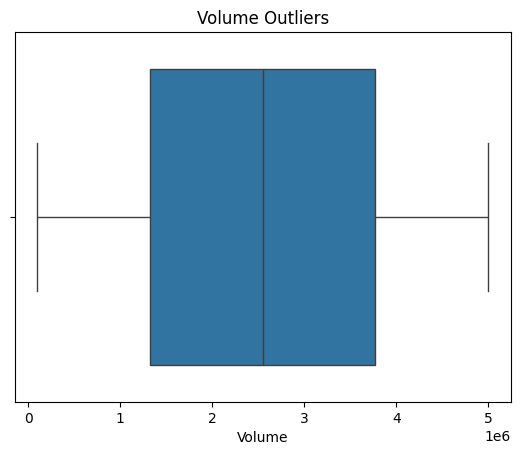

In [15]:
if 'Volume' in df.columns:
    sns.boxplot(x=df['Volume'])
    plt.title("Volume Outliers")
    plt.show()

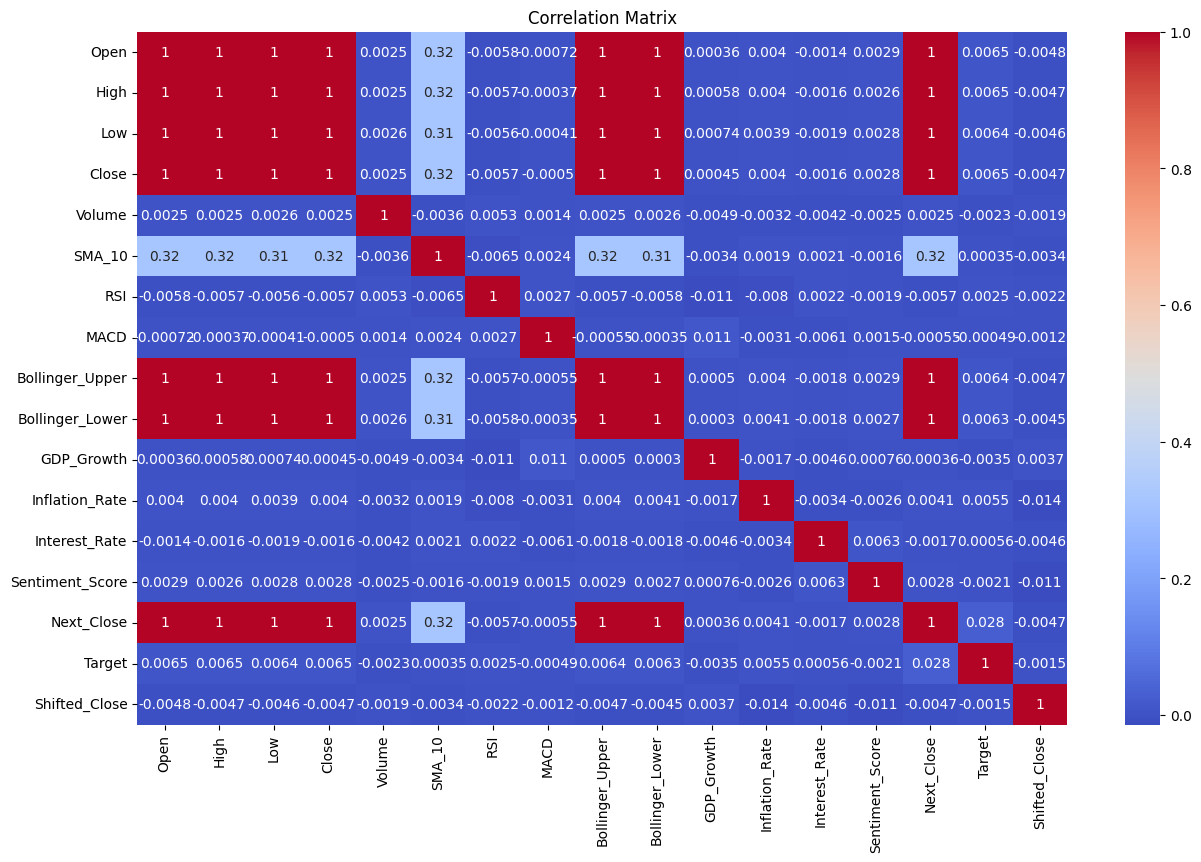

In [17]:
# 10. Correlation matrix
plt.figure(figsize=(15,9))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [20]:
#11.Are there negative values in Close, Open, MACD, etc.?
numeric_cols = df.select_dtypes(include=[np.number]).columns
negatives = (df[numeric_cols] < 0).any()
print(negatives)

Open               False
High               False
Low                False
Close              False
Volume             False
SMA_10             False
RSI                False
MACD                True
Bollinger_Upper    False
Bollinger_Lower    False
GDP_Growth         False
Inflation_Rate     False
Interest_Rate      False
Sentiment_Score     True
Next_Close         False
Target             False
Shifted_Close      False
dtype: bool


In [22]:
# 12.

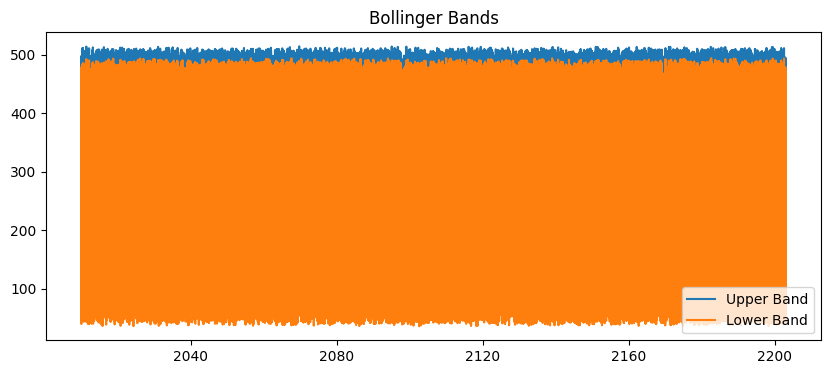

In [26]:
#13.Do Bollinger Bands make sense?
plt.figure(figsize=(10,4))
#plt.plot(df['Date'], df['Close'], label="Close")
plt.plot(df['Date'], df['Bollinger_Upper'], label="Upper Band")
plt.plot(df['Date'], df['Bollinger_Lower'], label="Lower Band")
plt.legend()
plt.title("Bollinger Bands")
plt.show()

In [27]:
# 14. Sentiment Score standardized?
print("Sentiment Score Range:", df['Sentiment_Score'].min(), "to", df['Sentiment_Score'].max())


Sentiment Score Range: -0.9999212930740472 to 0.9999661752348248


In [28]:
# 15. Average trading volume
print("Average trading volume:", df['Volume'].mean())

Average trading volume: 2547134.0776579473


In [30]:
# 16. % data with RSI > 70
print("% of RSI > 70:", (df['RSI'] > 70).mean() * 100, "%")


% of RSI > 70: 24.814792746628534 %


In [31]:
 #17. Monotonic Date
print("\nDates monotonic increasing:", df['Date'].is_monotonic_increasing)



Dates monotonic increasing: False


In [32]:
#18. Detect anomalies using Z-Score.
from scipy.stats import zscore
z_scores = np.abs(zscore(df[numeric_cols].dropna()))
anomalies = (z_scores > 3).any(axis=1)
print("\nNumber of anomalies detected (Z-score > 3):", anomalies.sum())


Number of anomalies detected (Z-score > 3): 94


In [33]:
#19. Consecutive trading days check
date_diff = df['Date'].diff().dt.days.dropna()
print("\nUnique day gaps in trading days:", date_diff.unique())


Unique day gaps in trading days: [ 1.0000e+00  2.0000e+00  4.0000e+00  9.0000e+00  1.4000e+01  7.0000e+00
  6.0000e+00  0.0000e+00  3.0000e+00  1.5000e+01  1.8000e+01  5.0000e+00
  1.3000e+01  1.2000e+01  8.0000e+00  1.1000e+01  1.9000e+01  1.6000e+01
  1.7000e+01  2.1000e+01  1.0000e+01  2.0000e+01  2.9000e+01  2.8000e+01
  2.3000e+01  4.1000e+01  2.2000e+01  2.6000e+01  3.0000e+01  2.7000e+01
  3.5000e+01  2.4000e+01  3.4000e+01  3.3000e+01  3.7000e+01  3.9000e+01
  3.2000e+01  4.0000e+01  4.4000e+01  3.6000e+01  4.9000e+01  4.2000e+01
  3.8000e+01  2.5000e+01  3.1000e+01  4.3000e+01  4.7000e+01  4.6000e+01
  6.2000e+01  5.1000e+01  5.6000e+01  5.0000e+01  5.5000e+01  5.7000e+01
  5.9000e+01 -7.0476e+04  5.3000e+01  4.8000e+01  5.4000e+01  5.2000e+01
  6.4000e+01  5.8000e+01 -7.0479e+04  4.5000e+01 -7.0474e+04  6.5000e+01
  7.0000e+01  6.8000e+01]


In [35]:
# 20. Any zero or negative OHLC values
ohlc_cols = ['Open','Close','High','Low']
zeros_negatives = (df[ohlc_cols] <= 0).any()
print("Zero/Negative values in OHLC:\n", zeros_negatives)

Zero/Negative values in OHLC:
 Open     False
Close    False
High     False
Low      False
dtype: bool
